<a href="https://colab.research.google.com/github/sarthakpol7117-droid/neon-blaster/blob/main/codomax_3_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Quick cleanup from Module 2, so charts don't break on missing data
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

sns.set_style('whitegrid')   # nicer default look for all charts below

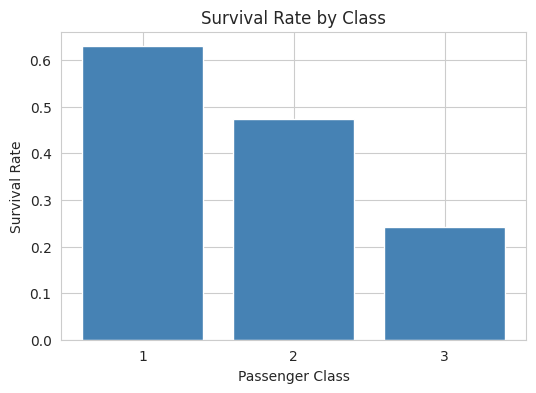

In [ ]:
survival_by_class = df.groupby('Pclass')['Survived'].mean()

plt.figure(figsize=(6, 4))
plt.bar(survival_by_class.index, survival_by_class.values, color='steelblue')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Class')
plt.xticks([1, 2, 3])
plt.show()

/tmp/ipykernel_2480/1012915665.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Pclass', y='Survived', errorbar=None, palette='Blues_d')


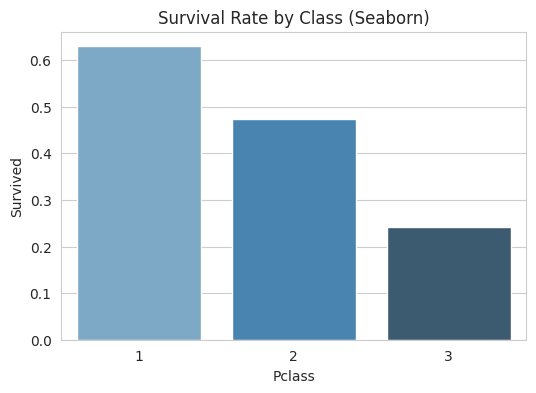

In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Pclass', y='Survived', errorbar=None, palette='Blues_d')
plt.title('Survival Rate by Class (Seaborn)')
plt.show()

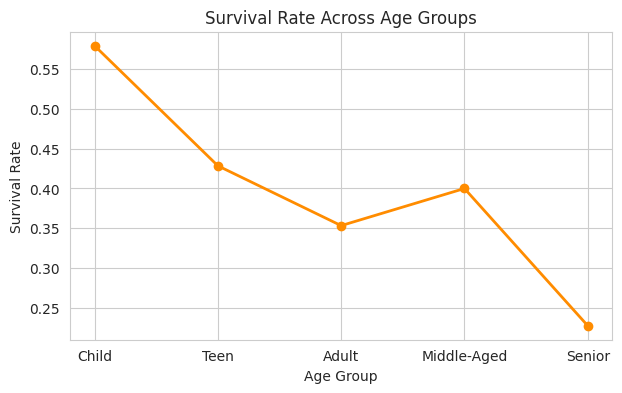

In [ ]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100],
                         labels=['Child', 'Teen', 'Adult', 'Middle-Aged', 'Senior'])

survival_by_age = df.groupby('AgeGroup', observed=True)['Survived'].mean()

plt.figure(figsize=(7, 4))
plt.plot(survival_by_age.index, survival_by_age.values, marker='o', color='darkorange', linewidth=2)
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.title('Survival Rate Across Age Groups')
plt.show()

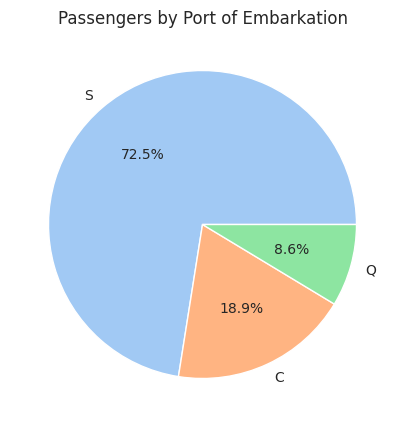

In [ ]:
embarked_counts = df['Embarked'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(embarked_counts.values, labels=embarked_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('pastel'))
plt.title('Passengers by Port of Embarkation')
plt.show()

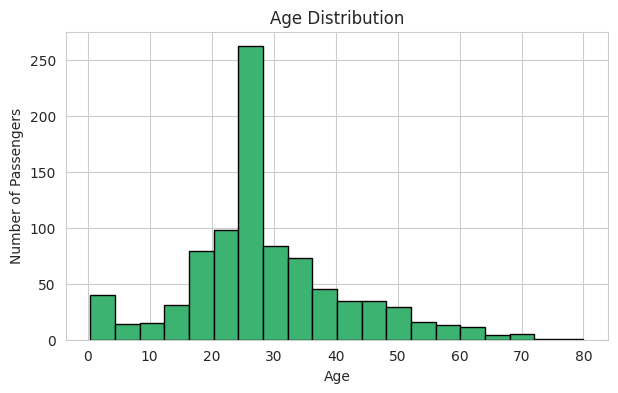

In [ ]:
plt.figure(figsize=(7, 4))
plt.hist(df['Age'], bins=20, color='mediumseagreen', edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.title('Age Distribution')
plt.show()

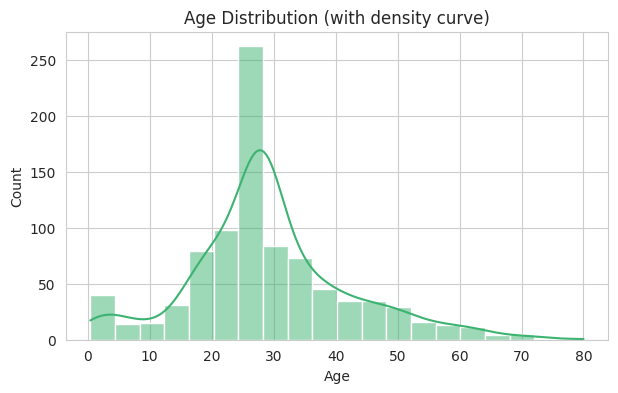

In [ ]:
# Seaborn version, with a smoothed density curve overlaid
plt.figure(figsize=(7, 4))
sns.histplot(df['Age'], bins=20, kde=True, color='mediumseagreen')
plt.title('Age Distribution (with density curve)')
plt.show()

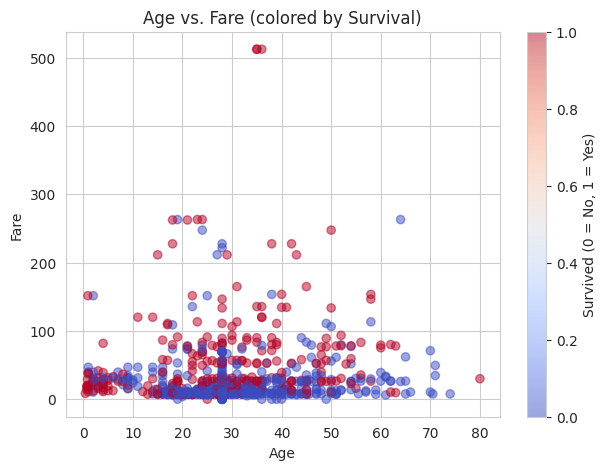

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(df['Age'], df['Fare'], alpha=0.5, c=df['Survived'], cmap='coolwarm')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Age vs. Fare (colored by Survival)')
plt.colorbar(label='Survived (0 = No, 1 = Yes)')
plt.show()

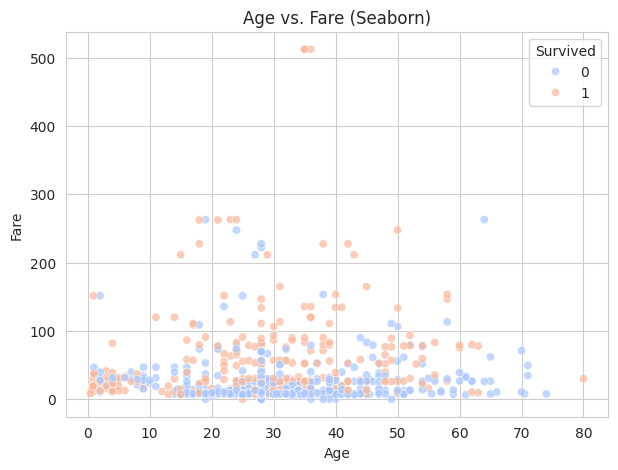

In [ ]:
# Seaborn version — automatically color-codes by category and adds a legend
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='Age', y='Fare', hue='Survived', palette='coolwarm', alpha=0.7)
plt.title('Age vs. Fare (Seaborn)')
plt.show()

/tmp/ipykernel_2480/3502584011.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Pclass', y='Survived', errorbar=None, ax=axes[0, 0], palette='Blues_d')


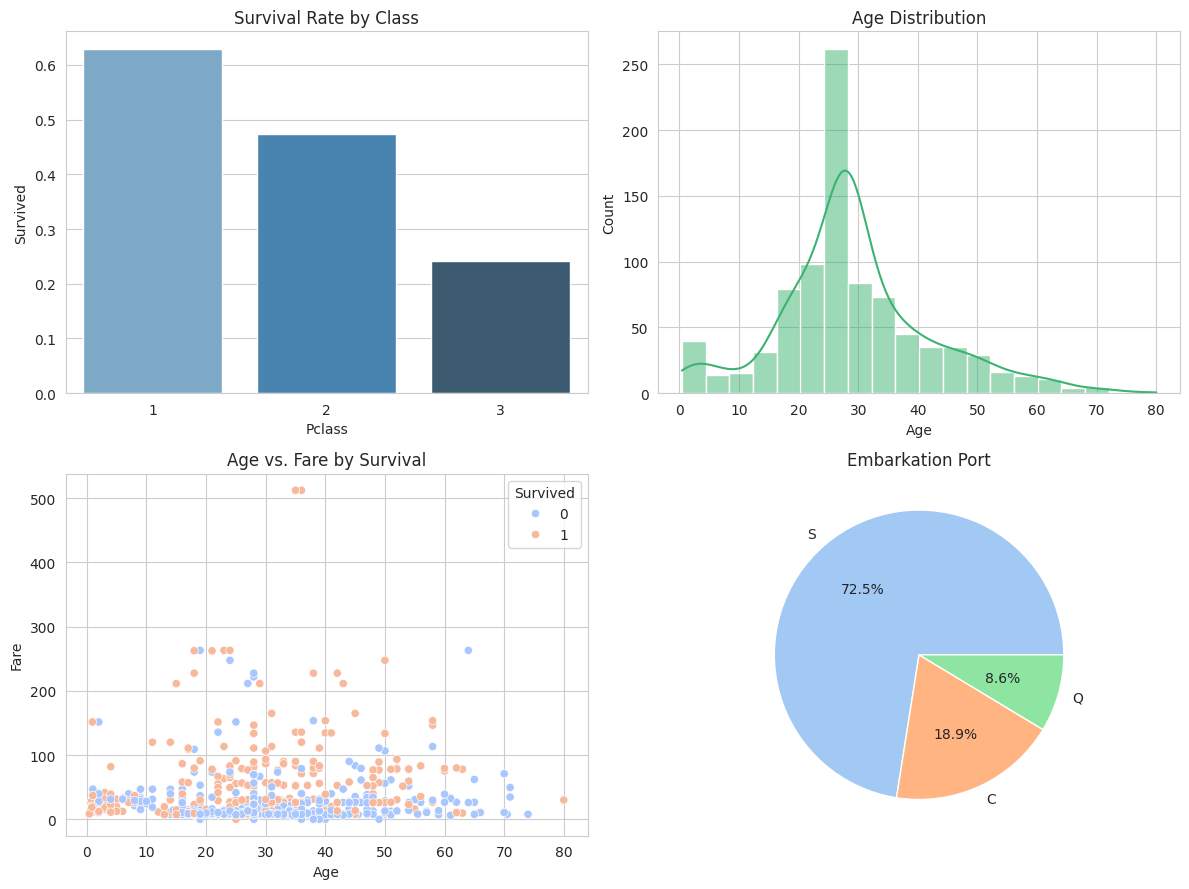

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.barplot(data=df, x='Pclass', y='Survived', errorbar=None, ax=axes[0, 0], palette='Blues_d')
axes[0, 0].set_title('Survival Rate by Class')

sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0, 1], color='mediumseagreen')
axes[0, 1].set_title('Age Distribution')

sns.scatterplot(data=df, x='Age', y='Fare', hue='Survived', palette='coolwarm', ax=axes[1, 0])
axes[1, 0].set_title('Age vs. Fare by Survival')

df['Embarked'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1, 1], colors=sns.color_palette('pastel'))
axes[1, 1].set_ylabel('')
axes[1, 1].set_title('Embarkation Port')

plt.tight_layout()
plt.show()